# Ejercicio de Regresion Lineal

La idea de este trabajo es tratar de predecir cuánto le cuesta a una empresa un problema de seguridad informática dependiendo de cuántos computadores se infecten.

### 1. Preparando los datos

In [1]:
import numpy as np

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)  # Generamos datos de prueba

print(f"La longitud del conjunto de datos es: {len(X)}")

La longitud del conjunto de datos es: 100


### 2. Visualizacion del conjunto de datos

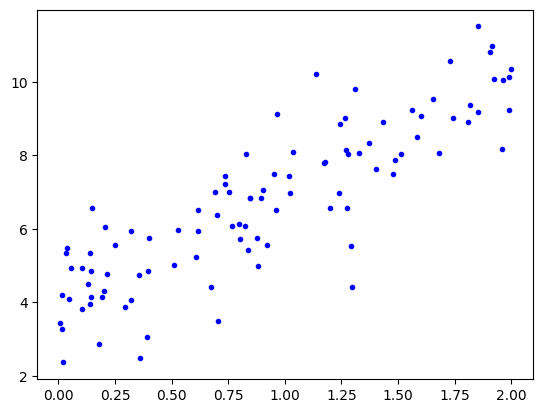

In [2]:
# Graficamos para ver como se ven los puntos
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(X, y, "b.")
plt.show()

### 3. Modificacion del conjunto de datos

In [3]:
import pandas as pd
data = {'n_equipos_afectados': X.flatten(), 'coste': y.flatten()}
df = pd.DataFrame(data)
df.head(10)

,n_equipos_afectados,coste
0,0.048403,4.089111
1,0.698442,6.376281
2,0.140675,3.963820
3,0.103211,4.946873
4,0.616207,6.521094
5,0.145604,4.851061
6,1.965534,10.051543
7,0.016001,3.282613
8,0.733932,7.449984
9,0.216616,4.769725


In [4]:
# Escalado del número de equipos afectados
df['n_equipos_afectados'] = df['n_equipos_afectados'] * 1000
df['n_equipos_afectados'] = df['n_equipos_afectados'].astype('int')
# Escalado del coste
df['coste'] = df['coste'] * 10000
df['coste'] = df['coste'].astype('int')
df.head(10)

,n_equipos_afectados,coste
0,48,40891
1,698,63762
2,140,39638
3,103,49468
4,616,65210
5,145,48510
6,1965,100515
7,16,32826
8,733,74499
9,216,47697


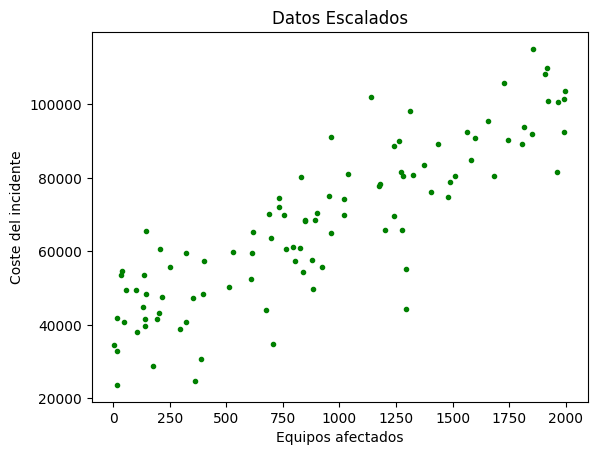

In [5]:
# Representacion gráfica del conjunto de datos

plt.plot(df['n_equipos_afectados'], df['coste'], "g.")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente")
plt.title("Datos Escalados")
plt.show()

### 4. Construccion del modelo

Entrenamos el modelo de Regresion Lineal para encontrar la relacion entre equipos y costes.

Parámetro theta 0 (Intercept): 39301.39800954187
Parámetro theta 1 (Coeficiente): 30.610322669487417


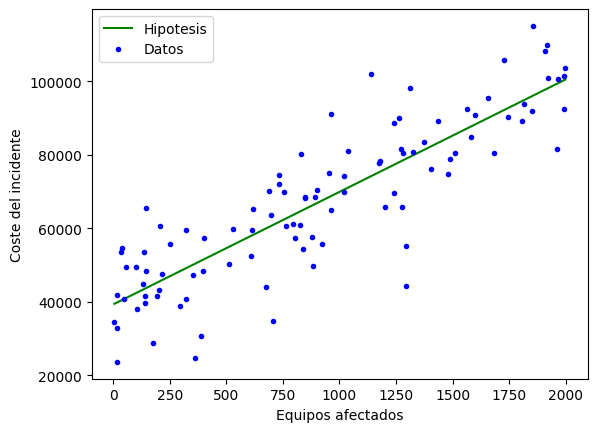

In [6]:
from sklearn.linear_model import LinearRegression

# Construccion del modelo y ajuste de la funcion hipotesis
lin_reg = LinearRegression()
lin_reg.fit(df['n_equipos_afectados'].values.reshape(-1, 1), df['coste'].values)

print("Parámetro theta 0 (Intercept):", lin_reg.intercept_)
print("Parámetro theta 1 (Coeficiente):", lin_reg.coef_[0])

# Prediccion para el valor mínimo y máximo para dibujar la línea
X_min_max = np.array([[df["n_equipos_afectados"].min()], [df["n_equipos_afectados"].max()]])
y_train_pred = lin_reg.predict(X_min_max)

# Plot de la funcion hipotesis generada
plt.plot(X_min_max, y_train_pred, "g-", label="Hipotesis")
plt.plot(df['n_equipos_afectados'], df['coste'], "b.", label="Datos")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente")
plt.legend()
plt.show()

### 5. Prediccion de nuevos ejemplos

Predecimos el coste para un incidente con 1300 equipos afectados.

El coste del incidente sería: 79094 €


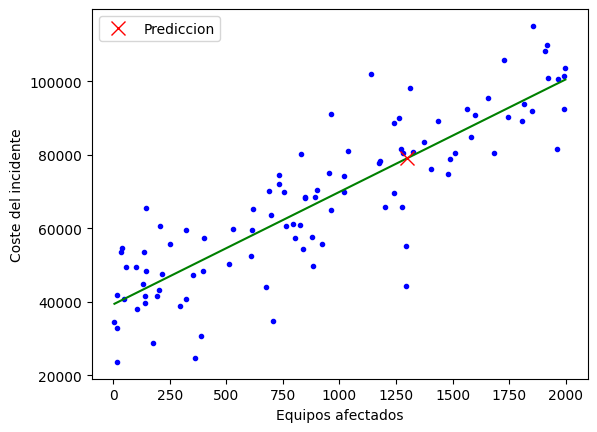

In [7]:
x_new = np.array([[1300]]) 
coste = lin_reg.predict(x_new) 

print("El coste del incidente sería:", int(coste[0]), "€")

plt.plot(df['n_equipos_afectados'], df['coste'], "b.")
plt.plot(X_min_max, y_train_pred, "g-")
plt.plot(x_new, coste, "rx", markersize=10, label="Prediccion")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente")
plt.legend()
plt.show()